In [5]:
from langgraph.graph import StateGraph, START, END
from typing import TypedDict,Literal

In [6]:
class State(TypedDict):
    a: int
    b: int
    c: int
    equation: str
    discrimnant:float
    root1:str
    root2:str

In [7]:
from math import sqrt

def create_eqn(old_state:State) ->State:
    eqn = f"{old_state['a']}x^2 + {old_state['b']}x + {old_state['c']}"

    return {'equation':eqn}

def calculate_D(old_state:State) ->State:
    a = old_state['a']
    b = old_state['b']
    c = old_state['c']
    D = (b**2) - (4*a*c)

    return {"discrimnant":D}

def real_roots(old_state:State) ->State:
    a = old_state['a']
    b = old_state['b']
    discrimnant = old_state['discrimnant']

    root1 = (-b + sqrt(discrimnant)) / (2 * a)
    root2 = (-b - sqrt(discrimnant)) / (2 * a)

    return {"root1":root1,"root2":root2}

def repeated_real_roots(old_state:State) ->State:
    a = old_state['a']
    b = old_state['b']

    root1 = -b  / (2 * a)
    root2 = root1

    return {"root1":root1,"root2":root2}

def no_real_roots(old_state:State) ->State:
    return {"root1":"No real roots","root2":"No real roots"}

def roots_router(old_state:State) -> Literal["real_roots","repeated_real_roots","no_real_roots"]:
    discrimnant = old_state['discrimnant']
    if discrimnant > 0:
        return "real_roots"
    elif discrimnant == 0:
        return "repeated_real_roots"
    else:
        return "no_real_roots"

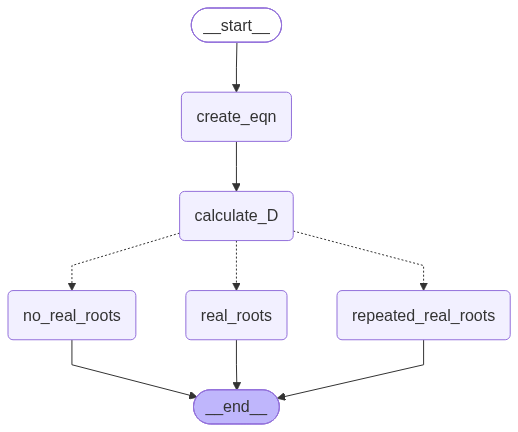

In [9]:
graph = StateGraph(State)

graph.add_node("create_eqn",create_eqn)
graph.add_node("calculate_D",calculate_D)
graph.add_node("real_roots",real_roots)
graph.add_node("repeated_real_roots",repeated_real_roots)
graph.add_node("no_real_roots",no_real_roots)


graph.add_edge(START,"create_eqn")
graph.add_edge("create_eqn","calculate_D")

graph.add_conditional_edges("calculate_D",roots_router)
graph.add_edge("real_roots",END)
graph.add_edge("repeated_real_roots",END)
graph.add_edge("no_real_roots",END)

workflow = graph.compile()
workflow

In [12]:
input_data = {"a":2,"b":-4,"c":2}
result=workflow.invoke(input_data)
result

{'a': 2,
 'b': -4,
 'c': 2,
 'equation': '2x^2 + -4x + 2',
 'discrimnant': 0,
 'root1': 1.0,
 'root2': 1.0}